# Teoria da Decisão & Inferência Bayesiana Aplicada: Lotofácil
### Modelagem Probabilística e Tomada de Decisão Ótima sob Incerteza

> **Fundamentação Metodológica:**
> Este projeto constitui um laboratório analítico e computacional que transpõe para o contexto empírico das loterias da Caixa Econômica Federal as noções teóricas e metodológicas fundamentadas na literatura de **Inferência Bayesiana e Teoria da Decisão** — inspirando-se particularmente na abordagem dos professores **Luís Gustavo Esteves, Rafael Izbicki e Rafael Bassi Stern** (*Aprendizado de Máquina sob a Ótica Bayesiana* e *Inferência Bayesiana e Teoria da Decisão*).
> 
> Sob esta perspectiva, a elaboração de uma aposta deixa de ser tratada como um mero palpite empírico e passa a ser formulada com o rigor de um **problema estatístico de decisão sob incerteza**: definindo formalmente o espaço de alternativas do apostador, a incerteza sobre o sorteio, a atualização racional de crenças a partir dos dados e a escolha da aposta que maximiza a utilidade esperada a posteriori.

---

## Estrutura do Estudo e Dinâmica do Jogo
Na modalidade **Lotofácil**, o volante é composto por **25 dezenas**, das quais exatamente **15 dezenas** são sorteadas por concurso.

Implementamos e comparamos **3 métodos analíticos complementares**:

1. **Método 1 (Estatístico / Frequência Ponderada & Atraso):** Abordagem heurística que pondera a taxa temporal recente de saídas com a métrica de atraso relativo (pressão de retorno à média empírica).
2. **Método 2 (Machine Learning Supervisionado Multi-label):** Aprendizado estatístico via *Binary Relevance* com Regressão Logística calibrada L2, baseado em janelas móveis multiescala e defasagens temporais (*lags*), com rígido controle contra vazamento de dados (*zero lookahead bias*).
3. **Método 3 (Inferência Bayesiana & Teoria da Decisão):** Modelo conjugado Beta-Binomial com **priori racional justa** $\text{Beta}(6.0, 4.0)$, cuja esperança a priori reflete exatamente a probabilidade teórica neutra de cada bola:
   $$\mathbb{E}[\theta_i] = \frac{15}{25} = 0.60$$
   A seleção final decorre da formalização do problema de decisão $(\mathcal{A}, \Theta, P, U)$ pela **Alternativa de Bayes**, selecionando as dezenas que maximizam a utilidade esperada a posteriori.

In [1]:
import sys
import os

# Garante que o módulo mega_sena_models seja localizado a partir da raiz ou de notebooks/
for path_cand in ['.', '..', os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(path_cand, 'mega_sena_models.py')):
        abs_cand = os.path.abspath(path_cand)
        if abs_cand not in sys.path:
            sys.path.insert(0, abs_cand)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mega_sena_models import (
    load_lottery_data,
    find_latest_lottery_file,
    compute_delay_statistics,
    FrequencyDelayModel,
    MultiLabelMLModel,
    BayesianDecisionModel,
    run_all_lottery_methods
)

# Configurações de exibição
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 5)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

EXCEL_PATH = find_latest_lottery_file('lotofacil')
df, binary_matrix, cfg = load_lottery_data(EXCEL_PATH, game='lotofacil')

print(f"Loteria: {cfg['name']} ({cfg['n_dezenas']} dezenas totais, {cfg['k']} dezenas por concurso)")
print(f"Total de concursos carregados: {len(df)}")
print(f"Primeiro concurso: {df.iloc[0]['Concurso']} ({df.iloc[0]['Data']})")
print(f"Último concurso: {df.iloc[-1]['Concurso']} ({df.iloc[-1]['Data']})")
print(f"Formato da matriz binária de ocorrências: {binary_matrix.shape}")

Loteria: Lotofácil (25 dezenas totais, 15 dezenas por concurso)
Total de concursos carregados: 3796
Primeiro concurso: 1 (29/09/2003)
Último concurso: 3796 (03/10/2026)
Formato da matriz binária de ocorrências: (3796, 25)


---
## Método 1: Abordagem Estatística (Frequência Ponderada & Atraso Relativo)

### Fundamentação Teórica e Intuição Heurística
Este método equilibra duas forças estatísticas comumente observadas em séries temporais de processos estocásticos:

1. **Frequência Ponderada no Tempo ($f_{w, i}$):**
   Aplica um decaimento exponencial temporal com meia-vida de 100 concursos:
   $$w_t = 2^{-(T - t) / 100}$$
   Isso atribui peso progressivamente maior aos concursos recentes, captando eventuais micro-tendências ou assimetrias temporárias no regime físico dos sorteios.

2. **Métrica de Atraso Relativo ($R_i$):**
   Calcula a razão entre o atraso corrente $d_i$ (número de concursos consecutivos em que a dezena $i$ não é sorteada) e seu intervalo médio histórico de espera $\mu_{\text{gap}, i}$:
   $$R_i = \frac{d_i}{\mu_{\text{gap}, i}}$$
   Quando $R_i > 1$, a dezena está demorando mais para sair do que seu padrão histórico médio.

3. **Escore Padronizado Balanceado:**
   Para unificar duas variáveis com escalas e naturezas distintas, aplica-se a normalização Z-Score:
   $$S_i = 0.5 \cdot Z(f_{w, i}) + 0.5 \cdot Z(R_i)$$

O método gera 3 perfis de decisão para análise:
- **Balanceado:** Combina momento recente com pressão de atraso.
- **Mais Atrasadas:** Foco em dezenas com maior déficit empírico.
- **Mais Frequentes Recentes:** Foco no momento atual (*momentum* temporal).

Top 15 Método 1 (Balanceado): [1, 2, 3, 4, 5, 6, 11, 12, 13, 14, 15, 17, 23, 24, 25]
Top 15 Método 1 (Mais Atrasadas): [1, 2, 7, 8, 10, 13, 14, 16, 17, 18, 19, 21, 22, 23, 25]
Top 15 Método 1 (Mais Frequentes Recentes): [1, 3, 4, 5, 6, 9, 11, 12, 13, 14, 15, 21, 23, 24, 25]


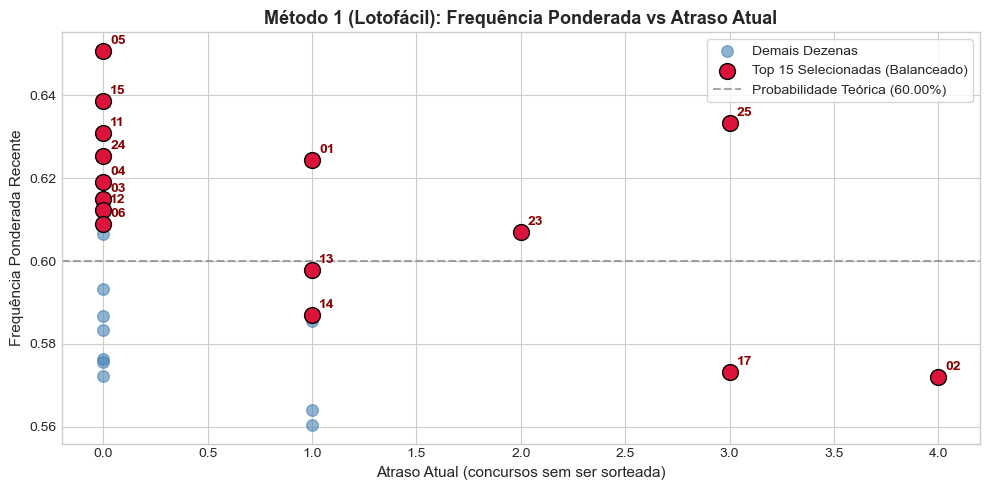

In [2]:
# Treinando o Método 1
m1 = FrequencyDelayModel(half_life=100.0, alpha=0.5)
m1.fit(binary_matrix)
df_m1 = m1.get_scores_df()

pred_m1_bal = m1.predict_top_k(15, strategy='balanced')
pred_m1_over = m1.predict_top_k(15, strategy='overdue')
pred_m1_mom = m1.predict_top_k(15, strategy='momentum')

print(f"Top 15 Método 1 (Balanceado): {pred_m1_bal}")
print(f"Top 15 Método 1 (Mais Atrasadas): {pred_m1_over}")
print(f"Top 15 Método 1 (Mais Frequentes Recentes): {pred_m1_mom}")

# Visualização: Atraso Atual vs Frequência Ponderada
fig, ax = plt.subplots(figsize=(10, 5))
selected_mask = df_m1['dezena'].isin(pred_m1_bal)

ax.scatter(df_m1.loc[~selected_mask, 'atraso_atual'], 
           df_m1.loc[~selected_mask, 'freq_ponderada'],
           c='steelblue', alpha=0.6, s=70, label='Demais Dezenas')

ax.scatter(df_m1.loc[selected_mask, 'atraso_atual'], 
           df_m1.loc[selected_mask, 'freq_ponderada'],
           c='crimson', edgecolors='black', s=130, zorder=5, label=f'Top 15 Selecionadas (Balanceado)')

for _, r in df_m1[selected_mask].iterrows():
    ax.annotate(f"{int(r['dezena']):02d}", 
                (r['atraso_atual'], r['freq_ponderada']),
                textcoords="offset points", xytext=(5, 5), fontweight='bold', color='darkred')

ax.set_title(f"Método 1 (Lotofácil): Frequência Ponderada vs Atraso Atual", fontsize=13, fontweight='bold')
ax.set_xlabel("Atraso Atual (concursos sem ser sorteada)", fontsize=11)
ax.set_ylabel("Frequência Ponderada Recente", fontsize=11)
ax.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label=f'Probabilidade Teórica (60.00%)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## Método 2: Machine Learning Supervisionado Multi-label

### Engenharia de Atributos e Aprendizado com Validação Temporal
Neste método, o desafio de prever as dezenas é modelado como um problema de classificação supervisionada multi-rótulo:

1. **Estratégia *Binary Relevance*:**
   Treinam-se 25 modelos independentes (um para cada dezena $i \in \{1, \dots, 25\}$). Cada modelo aprende a função de probabilidade:
   $$P\left(Y_i^{(t+1)} = 1 \mid \mathbf{x}_i^{(t)}\right)$$

2. **Engenharia de Atributos Sem Vazamento de Dados (*Zero Data Leakage*):**
   O vetor de características $\mathbf{x}_i^{(t)}$ para o concurso $t+1$ utiliza **estritamente** os dados acumulados até o concurso $t$:
   - **Atraso corrente:** Número de sorteios sem sair até o momento $t$.
   - **Frequências móveis multiescala:** Taxa de aparição nas últimas $W$ rodadas ($W \in \{5, 10, 25, 50, 100\}$ concursos).
   - **Defasagens temporais (*Lags*):** Indicadores binários de saída nos concursos $t$, $t-1$ e $t-2$.
   - **Variável de contexto:** Contagem de dezenas pares sorteadas no concurso anterior.

3. **Modelo e Calibração:**
   Utiliza-se Regressão Logística com regularização $L_2$ ($C=0.1$) para evitar sobreajuste (*overfitting*). As probabilidades brutas estimadas são calibradas e normalizadas para que sua soma corresponda exatamente a 15 dezenas (o número de bolas sorteadas). As 15 dezenas com maiores probabilidades calibradas compõem a aposta.

Top 15 Método 2 (Machine Learning Calibrado): [1, 3, 5, 6, 10, 11, 12, 13, 14, 18, 20, 21, 23, 24, 25]


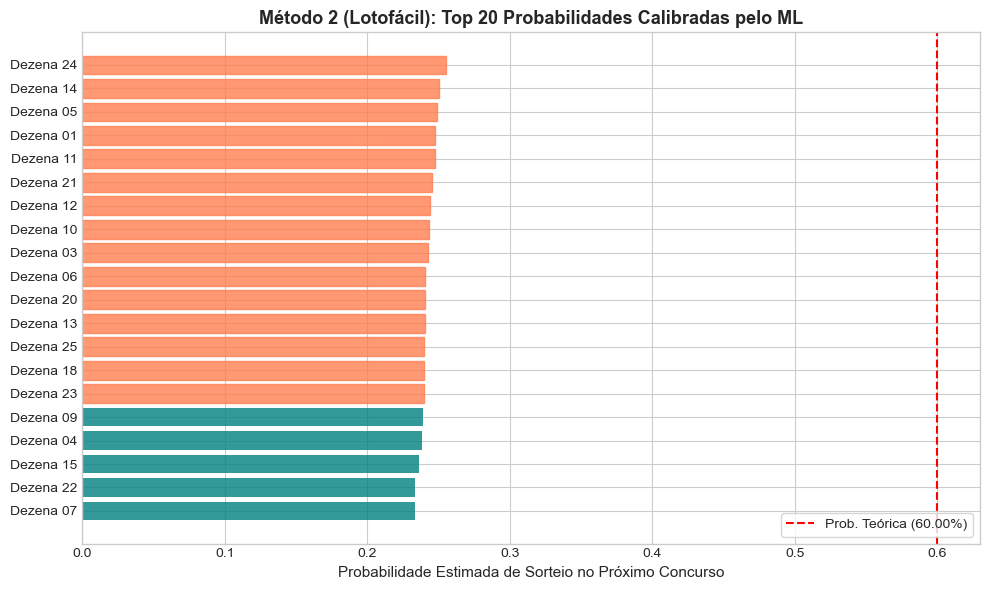

In [3]:
# Treinando o Método 2
m2 = MultiLabelMLModel(estimator='logistic_regression', random_state=42)
m2.fit(binary_matrix)
df_m2 = m2.get_probabilities_df()

pred_m2 = m2.predict_top_k(15)
print(f"Top 15 Método 2 (Machine Learning Calibrado): {pred_m2}")

# Visualização: Probabilidades Calibradas das Top Dezenas
top_display = min(20, 25)
top_df_m2 = df_m2.head(top_display).sort_values('probabilidade_calibrada_sorteio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(np.arange(len(top_df_m2)), top_df_m2['probabilidade_calibrada_sorteio'], color='teal', alpha=0.8)

# Destaque para as top K escolhidas
for i, (_, row) in enumerate(top_df_m2.iterrows()):
    if int(row['dezena']) in pred_m2:
        bars[i].set_color('coral')

ax.set_yticks(np.arange(len(top_df_m2)))
ax.set_yticklabels([f"Dezena {int(d):02d}" for d in top_df_m2['dezena']], fontsize=10)
ax.axvline(0.6, color='red', linestyle='--', linewidth=1.5, label=f'Prob. Teórica (60.00%)')
ax.set_title(f"Método 2 (Lotofácil): Top {top_display} Probabilidades Calibradas pelo ML", fontsize=13, fontweight='bold')
ax.set_xlabel("Probabilidade Estimada de Sorteio no Próximo Concurso", fontsize=11)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

---
## Método 3: Inferência Bayesiana & Teoria da Decisão

### 1. Formalização do Problema de Decisão $(\mathcal{A}, \Theta, P, U)$
Seguindo os princípios formais da Teoria da Decisão Estatística apresentados por **Esteves, Izbicki e Stern (Capítulo 6)**, estruturamos a aposta da seguinte forma:

* **Espaço de Ações (Decisões) $\mathcal{A}$:** O conjunto de todas as combinações possíveis de apostas $a = \{d_1, \dots, d_15\}$, com $d_j \in \{1, \dots, 25\}$.
* **Espaço de Estados da Natureza $\Theta$:** O resultado real do sorteio $s = \{s_1, \dots, s_15\}$.
* **Medida de Incerteza $P$:** Representada pela distribuição preditiva a posteriori $p(\theta \mid \mathcal{D})$, atualizada a partir do histórico observacional.
* **Função de Utilidade $U(a, s)$:** Recompensa o apostador pelo número de dezenas acertadas:
  $$U(a, s) = |a \cap s| = \sum_{i \in a} \mathbb{I}(i \in s)$$
* **Regra de Decisão de Bayes (Utilidade Esperada):**
  A **Alternativa de Bayes** $a^*$ é a ação que maximiza a utilidade esperada a posteriori:
  $$a^* = \arg\max_{a \in \mathcal{A}} \mathbb{E}[U(a, s) \mid \mathcal{D}] = \arg\max_{a \in \mathcal{A}} \sum_{i \in a} \mathbb{E}[\theta_i \mid \mathcal{D}]$$
  Portanto, a decisão ótima consiste em selecionar as **15 dezenas com as maiores esperanças a posteriori**.

---

### 2. O Modelo Conjugado Beta-Binomial (Capítulos 4 e 7)
Para cada dezena $i$, consideramos o sorteio como um processo Bernoulli com taxa desconhecida $\theta_i \in [0, 1]$.

* **Priori Racional Justa:**
  Adota-se uma distribuição a priori $\theta_i \sim \text{Beta}(6.0, 4.0)$, com peso inicial equivalente a 10 concursos teóricos e esperança neutra idêntica à probabilidade matemática do jogo:
  $$\mathbb{E}[\theta_i] = \frac{\alpha_0}{\alpha_0 + \beta_0} = \frac{15}{25} = 0.60$$
* **Verossimilhança:** $X_i \mid \theta_i \sim \text{Binomial}(n, \theta_i)$.
* **Posteriori Exata (Lema 4.31):** Pela propriedade de conjugação:
  $$\theta_i \mid X_i = x_i \sim \text{Beta}(\alpha_0 + x_i, \; \beta_0 + n - x_i)$$
* **Esperança a Posteriori (Lema 4.32) e Intervalo de Credibilidade (95%):**
  $$\mathbb{E}[\theta_i \mid x_i] = \frac{\alpha_0 + x_i}{\alpha_0 + \beta_0 + n}$$

---

### 3. As Duas Abordagens Bayesianas: Global vs. Adaptativo
Calculamos e comparamos duas formulações da decisão bayesiana:

* **Conjugado Global (Histórico Total):** Considera todos os concursos de forma cumulativa com pesos iguais. É altamente estável e mede a tendência estrutural de longo prazo, com intervalos de credibilidade muito estreitos.
* **Dinâmico Adaptativo (Ponderado no Tempo):** Aplica fator de decaimento exponencial (meia-vida de 200 concursos) nas contagens pseudo-amostrais ($n_{\text{eff}} \approx 288$). Foca no regime físico e mecânico recente dos sorteios.

Top 15 Decisão Ótima de Bayes (Conjugado Global): [1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15, 20, 24, 25]
Top 15 Decisão Ótima de Bayes (Dinâmico Adaptativo): [1, 3, 4, 5, 6, 7, 9, 11, 12, 13, 15, 21, 23, 24, 25]


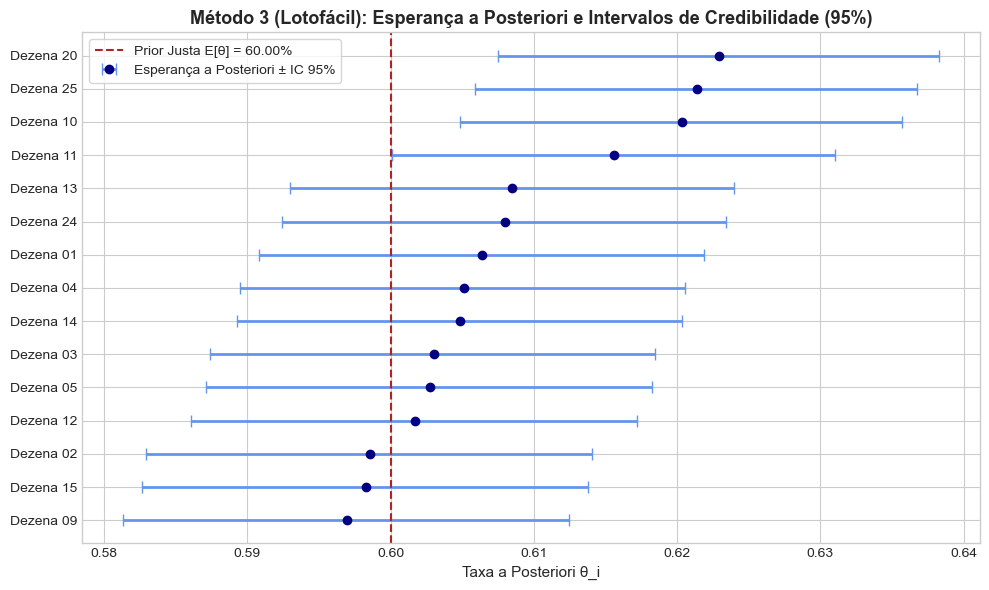

In [4]:
# 3a. Modelo Bayesiano Conjugado Global
m3_static = BayesianDecisionModel(alpha_0=6.0, beta_0=4.0)
m3_static.fit(binary_matrix)
df_m3 = m3_static.get_posterior_df()

pred_m3_static = m3_static.predict_top_k(15)
print(f"Top 15 Decisão Ótima de Bayes (Conjugado Global): {pred_m3_static}")

# 3b. Modelo Bayesiano Dinâmico Adaptativo (Decaimento Temporal)
m3_dyn = BayesianDecisionModel(alpha_0=6.0, beta_0=4.0, decay_half_life=150.0)
m3_dyn.fit(binary_matrix)
pred_m3_dyn = m3_dyn.predict_top_k(15)
print(f"Top 15 Decisão Ótima de Bayes (Dinâmico Adaptativo): {pred_m3_dyn}")

# Visualização: Intervalos de Credibilidade de 95%
n_show = min(15, 25)
df_ci = df_m3.head(n_show).copy()

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(df_ci))
ax.errorbar(df_ci['esperanca_posteriori'], y_positions,
            xerr=[df_ci['esperanca_posteriori'] - df_ci['ci_95_inf'],
                  df_ci['ci_95_sup'] - df_ci['esperanca_posteriori']],
            fmt='o', color='navy', ecolor='cornflowerblue', elinewidth=2, capsize=4,
            label='Esperança a Posteriori ± IC 95%')

ax.axvline(0.6, color='firebrick', linestyle='--', linewidth=1.5, label=f'Prior Justa E[θ] = 60.00%')
ax.set_yticks(y_positions)
ax.set_yticklabels([f"Dezena {int(d):02d}" for d in df_ci['dezena']], fontsize=10)
ax.set_title(f"Método 3 (Lotofácil): Esperança a Posteriori e Intervalos de Credibilidade (95%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Taxa a Posteriori θ_i", fontsize=11)
ax.invert_yaxis()
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## Comparação Consolidada dos 3 Métodos
Abaixo sintetizamos as 15 dezenas recomendadas por cada abordagem analítica e identificamos a **análise de consenso (dezenas com convergência de múltiplos modelos)**.

In [5]:
next_concurso = int(df['Concurso'].max()) + 1
results = run_all_lottery_methods(EXCEL_PATH, game='lotofacil', next_concurso=next_concurso)
comp_df = results['comparison_df']

print("=" * 85)
print(f"QUADRO RESUMO DE ESTIMATIVAS - LOTOFÁCIL (CONCURSO {next_concurso})")
print("=" * 85)
for idx, row in comp_df.iterrows():
    print(f"{row['Metodo']:<50} : {row['Dezenas Previstas']}")
print("=" * 85)

# Consenso e contagem de votos
all_suggested = []
for k_model in ['Metodo 1 (Estatistico - Balanceado)', 
                'Metodo 2 (Machine Learning Multi-label Calibrado)', 
                'Metodo 3 (Bayesiano Conjugado Global)',
                'Metodo 3 (Bayesiano Dinamico Adaptativo)']:
    all_suggested.extend(results['predictions'][k_model])

freq_series = pd.Series(all_suggested).value_counts()
print(f"\nDezenas mais indicadas pelos modelos para o Concurso {next_concurso}:")
for dez, count in freq_series.items():
    if count >= 2:
        print(f"Dezena {dez:02d}: indicada por {count} abordagens")


QUADRO RESUMO DE ESTIMATIVAS - LOTOFÁCIL (CONCURSO 3797)
Metodo 1 (Estatistico - Balanceado)                : 01, 02, 03, 04, 05, 06, 11, 12, 13, 14, 15, 17, 23, 24, 25
Metodo 1 (Sub-estrategia Mais Atrasadas)           : 01, 02, 07, 08, 10, 13, 14, 16, 17, 18, 19, 21, 22, 23, 25
Metodo 1 (Sub-estrategia Mais Frequentes Recentes) : 01, 03, 04, 05, 06, 09, 11, 12, 13, 14, 15, 21, 23, 24, 25
Metodo 2 (Machine Learning Multi-label Calibrado)  : 01, 03, 05, 06, 10, 11, 12, 13, 14, 18, 20, 21, 23, 24, 25
Metodo 3 (Bayesiano Conjugado Global)              : 01, 02, 03, 04, 05, 09, 10, 11, 12, 13, 14, 15, 20, 24, 25
Metodo 3 (Bayesiano Dinamico Adaptativo)           : 01, 03, 04, 05, 06, 07, 09, 11, 12, 13, 15, 21, 23, 24, 25

Dezenas mais indicadas pelos modelos para o Concurso 3797:
Dezena 01: indicada por 4 abordagens
Dezena 03: indicada por 4 abordagens
Dezena 25: indicada por 4 abordagens
Dezena 05: indicada por 4 abordagens
Dezena 24: indicada por 4 abordagens
Dezena 11: indicada por 4 

---
## Considerações Críticas, Ética e Limitações Metodológicas

### 1. A Hipótese de Aleatoriedade e Independência Estatística
Do ponto de vista formal da física mecânica e da teoria dos jogos, os sorteios de loterias oficiais da Caixa são projetados para operar como variáveis aleatórias independentes e identicamente distribuídas (i.i.d.).
* Sob a hipótese de jogo estritamente justo, toda e qualquer combinação de 15 dezenas possui exatamente a mesma probabilidade matemática a priori de ser sorteada em cada concurso individual:
  $$P(\text{combinação}) = \frac{1}{\binom{25}{15}}$$

### 2. O Papel da Inferência Bayesiana e da Teoria da Decisão
Como destacam os professores **Esteves, Izbicki e Stern**, o objetivo da Teoria da Decisão Estatística sob incerteza **não é prometer previsões mágicas ou infalíveis**, mas sim fornecer um arcabouço formal, coerente e racional para organizar crenças, pesar evidências empíricas e selecionar a melhor ação sob uma determinada função de utilidade.

As contribuições desta modelagem são:
- **Racionalização da Escolha:** Substitui heurísticas intuitivas por formulações rigorosas de utilidade e probabilidade calibrada.
- **Transparência Epistêmica:** O Método Bayesiano explicita a incerteza residual através de Intervalos de Credibilidade a 95%, evitando a ilusão de certeza.
- **Consenso Analítico:** A combinação de modelos estruturais (longo prazo) com modelos dinâmicos (regime recente) maximiza a coerência da aposta frente à evidência disponível nos dados históricos.

---
### Referências Bibliográficas
* ESTEVES, Luís Gustavo; IZBICKI, Rafael; STERN, Rafael Bassi. *Aprendizado de Máquina sob a Ótica Bayesiana*.
* STERN, Rafael Bassi. *Inferência Bayesiana e Teoria da Decisão*.